In [5]:
import numpy as np
import networkx as nx
from collections import defaultdict

from QHyper.converter import Converter
from QHyper.constraint import Polynomial

from dwave.system import DWaveSampler
from dimod import BinaryQuadraticModel

from QHyper.problems.community_detection import CommunityDetectionProblem, Network


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

In [3]:
from Qommunity.samplers.hierarchical.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher


gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)
res_gur = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

comms_gur = res_gur.communities[0]
div_tree_gur = res_gur.division_tree[0]
div_mods_gur = res_gur.division_modularities[0]

100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


In [4]:
division_tree = div_tree_gur
communities = comms_gur
division_modularities = div_mods_gur

In [5]:
class Node:
    def __init__(self, id, values, left=None, right=None, parent=None):
        self.id = id
        self.values = values
        self.left = left
        self.right = right
        self.parent = parent

    def __str__(self):
        return f"Node(id={self.id}, values={self.values})"
    
    def __repr__(self):
        return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
    def __eq__(self, node):
        if not isinstance(node, Node):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

class Tree:
    def __init__(self, root):
        self.root = root
        self.nodes = [root]

In [6]:
def recover_ordering(division_tree):
    root = Node(id=hash(tuple(G.nodes)), values=list(G.nodes), left=None, right=None, parent=None)
    nodes = {}

    for level in reversed(range(len(division_tree))):
        level_clustering = division_tree[level]

        if level == len(division_tree) - 1:
            for cluster in level_clustering:
                leaf_node = Node(id=hash(tuple(cluster)), values=cluster, left=None, right=None, parent=None)
                nodes[leaf_node.id] = leaf_node
        else:
            subsequent_clusters = division_tree[level + 1]
            subclusters = {}

            for subsequent_cluster in subsequent_clusters: # children clusters
                for cluster in level_clustering: # parent clusters
                    if set(subsequent_cluster).issubset(set(cluster)): # if subsequent cluster is child of the parent
                        key_clus = hash(tuple(cluster))
                        
                        if key_clus not in subclusters.keys():
                            subclusters[key_clus] = subsequent_cluster
                        else:
                            subclusters[key_clus] = (
                                subclusters.get(key_clus),
                                subsequent_cluster,
                            )                    

            for cluster in level_clustering:
                key_clus = hash(tuple(cluster))

                if type(subclusters[key_clus]) == tuple:
                    c0, c1 = subclusters[key_clus]
                    key1, key2 = hash(tuple(c0)), hash(tuple(c1))

                    child_node_1 = nodes[key1]
                    child_node_2 = nodes[key2]

                    parent_node = Node(id=key_clus, values=cluster, left=child_node_1, right=child_node_2, parent=None)
                    nodes[parent_node.id] = parent_node

                    child_node_1.parent = parent_node
                    child_node_2.parent = parent_node
                    
                    # Sanity checks
                    assert child_node_1.parent == parent_node
                    assert child_node_2.parent == parent_node


                # only one subcommunity - list
                elif type(subclusters[key_clus]) == list and level != 0:
                    pass # Nothing to do in here

    root = nodes[root.id]
    return nodes, root

In [7]:
communities = communities
div_mods = division_modularities
div_tree = division_tree

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = division_modularities[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    # pr_id = comm_hash_to_pr_id[hash(tuple(values))]
    # chain_strength = pr_id_to_chain_strength[pr_id]
    # chain_strength = comm_hash_to_ch_str[hash(tuple(values))]
    chain_strength = 0.93

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level, chain_strength=chain_strength)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)

    
def center_parents(G, pos):
    """Center parents above children."""
    for n, data in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True):
        children = list(G.successors(n))
        if len(children) == 2:
            x1, _ = pos[children[0]]
            x2, _ = pos[children[1]]
            _, y = pos[n]
            pos[n] = ((x1 + x2)/2, y)
    return pos


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    center_parents(G, pos)

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']
        chain_strength = node_data['chain_strength']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {chain_strength}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [division_modularities[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [10]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher

In [11]:
adv_sampler = AdvantageSampler(G, num_reads=100, version="Advantage2_system1.7", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)

In [12]:
searcher = HierarchicalSearcher(adv_sampler)
res_adv = searcher.hierarchical_community_search(division_tree=True, return_modularities=True, return_metadata=True)

Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' ob

In [13]:
communities = res_adv[0]
division_tree = res_adv[1]
division_modularities = res_adv[2]
sampleset_metadata = res_adv[3]

In [15]:
nodes, root = recover_ordering(division_tree)

In [16]:
nodes

{7673536023032186979: Node(values=[34, 52, 94, 99], left=None, right=None),
 1817303922367657890: Node(values=[41], left=None, right=None),
 4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 -2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 -3174143701167733423: Node(values=[19, 38, 46, 49, 53, 76, 78, 80, 83], left=None, right=None),
 6558814328546076487: Node(values=[6, 12, 17, 35, 40, 65, 67, 74, 79, 90, 92, 98], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -3521112905008576525: Node(values=[36], left=None, right=None),
 508968978265049823: Node(values=[0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77,

In [17]:
def print_tree(node, level=0):
    if node is not None:
        print_tree(node.right, level + 1)
        print(' ' * 8 * level + '->', node)
        print_tree(node.left, level + 1)

In [18]:
print_tree(root)

                                -> Node(id=-3174143701167733423, values=[19, 38, 46, 49, 53, 76, 78, 80, 83])
                        -> Node(id=-6629042261135669948, values=[19, 36, 38, 46, 49, 53, 76, 78, 80, 83])
                                -> Node(id=-3521112905008576525, values=[36])
                -> Node(id=1635414667288543090, values=[19, 29, 36, 37, 38, 46, 49, 51, 53, 59, 61, 62, 63, 66, 70, 75, 76, 78, 80, 82, 83])
                        -> Node(id=7257540054485854263, values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82])
        -> Node(id=1369580326327729632, values=[1, 2, 3, 5, 7, 8, 10, 14, 15, 16, 19, 24, 25, 28, 29, 30, 31, 33, 36, 37, 38, 43, 46, 49, 51, 53, 54, 59, 60, 61, 62, 63, 66, 69, 70, 72, 73, 75, 76, 78, 80, 82, 83, 84, 86, 88, 91, 97])
                                -> Node(id=-2251870041769838549, values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91])
                        -> Node(id=3238314728115489754, values=[1, 2, 3, 7, 8, 14, 15, 16, 24, 33, 43, 5

In [19]:
from enum import Enum
from QHyper.solvers.base import SamplesetData
from dataclasses import dataclass, field
import numpy as np
from typing import Union, List, Dict, Any

In [ ]:
# from searchers.utils import MetadataFieldName

# # class Node:
# #     def __init__(self, id, values, left=None, right=None, parent=None):
# #         self.id = id
# #         self.values = values
# #         self.left = left
# #         self.right = right
# #         self.parent = parent

# #     def __str__(self):
# #         return f"Node(id={self.id}, values={self.values})"
    
# #     def __repr__(self):
# #         return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
# #     def __eq__(self, node):
# #         if not isinstance(node, Node):
# #             return False
# #         return self.id == node.id and sorted(self.values) == sorted(node.values)

# # class Tree:
# #     def __init__(self, root):
# #         self.root = root
# #         self.nodes = [root]


# # class DivisionNode:
# #     def __init__(self, community_hash, values, problem_id, chain_strength, chain_break_fraction, left=None, right=None, parent=None):
# #         self.id = community_hash
# #         self.values = values
# #         self.left = left
# #         self.right = right
# #         self.parent = parent

# #         # Additional data
# #         self.community_hash = community_hash
# #         self.problem_id = problem_id
# #         self.chain_strength = chain_strength
# #         self.chain_break_fraction = chain_break_fraction


# #     def __str__(self):
# #         return f"Node(id={self.id}, values={self.values})"
    
# #     def __repr__(self):
# #         return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
# #     def __eq__(self, node):
# #         if not isinstance(node, DivisionNode):
# #             return False
# #         return self.id == node.id and sorted(self.values) == sorted(node.values)


# @dataclass
# class HierarchicalRunMetadata:
#     dwave_sampleset_metadata: np.recarray = field(init=False)
#     time_measurements: np.recarray = field(init=False)
#     dwave_sampleset: List[Dict[str, Any]] = field(init=False)
#     timing: List[Dict[str, Any]] = field(init=False)
#     problem_id: List[Union[str, int, float]] = field(init=False)
#     community_hash: List[Union[str, int]] = field(init=False)
#     chain_strength: List[float] = field(init=False)
#     chain_break_fraction: List[float] = field(init=False)
#     chain_break_method: List[str] = field(init=False)
#     embedding: List[Dict[str, Any]] = field(init=False)
#     warnings: List[Dict[str, Any]] = field(init=False)

#     def __init__(self, sampleset: List[SamplesetData]):
#         self.dwave_sampleset_metadata = self._process_samples(
#             sampleset, MetadataFieldName.DwaveSamplesetMetadata.value
#         )
#         self.time_measurements = self._process_samples(
#             sampleset, MetadataFieldName.TimeMeasurements.value
#         )
#         self.dwave_sampleset = self._process_samples(
#             sampleset, MetadataFieldName.DWaveSampleset.value
#         )
#         self.timing = self._process_samples(
#             sampleset, MetadataFieldName.Timing.value
#         )
#         self.problem_id = self._process_samples(
#             sampleset, MetadataFieldName.ProblemID.value
#         )
#         self.community_hash = self._process_samples(
#             sampleset, MetadataFieldName.CommunityHash.value
#         )
#         self.chain_strength = self._process_samples(
#             sampleset, MetadataFieldName.ChainStrength.value
#         )
#         self.chain_break_fraction = self._process_samples(
#             sampleset, MetadataFieldName.ChainBreakFraction.value
#         )
#         self.chain_break_method = self._process_samples(
#             sampleset, MetadataFieldName.ChainBreakMethod.value
#         )
#         self.embedding = self._process_samples(
#             sampleset, MetadataFieldName.Embedding.value
#         )
#         self.warnings = self._process_samples(
#             sampleset, MetadataFieldName.Warnings.value
#         )


In [20]:
class DivisionNode:
    def __init__(self, community_hash: str | int, node: Node, sampleset_data: SamplesetData | None):
        self.community_hash: int | str = community_hash
        self.node: Node = node
        self.sampleset_data: SamplesetData | None = sampleset_data
        
    @property
    def id(self):
        return self.node.id

    @property
    def values(self):
        return self.node.values
    
    @property
    def left(self):
        return self.node.left
    
    @property
    def right(self):
        return self.node.right
    
    @property
    def parent(self):
        return self.node.parent
    
    @property
    def problem_id(self):
        return self.sampleset_data.problem_id if self.sampleset_data else None
    
    @property
    def chain_strength(self):
        return self.sampleset_data.chain_strength if self.sampleset_data else None
    
    @property
    def chain_break_fraction(self):
        return self.sampleset_data.chain_break_fraction if self.sampleset_data else None
    
    @property
    def chain_break_method(self):
        return self.sampleset_data.chain_break_method if self.sampleset_data else None
    
    def __str__(self):
        return f"ExtendedNode(id={self.id}, community={self.values}, left={self.left}, right={self.right}, community_hash={self.community_hash}, problem_id={self.problem_id}, chain_strength={self.chain_strength}, chain_break_fraction={self.chain_break_fraction}, chain_break_method={self.chain_break_method})"
    
    def __repr__(self):
        return f"ExtendedNode(id={self.id}, community={self.values}, left={self.left}, right={self.right}, community_hash={self.community_hash}, problem_id={self.problem_id}, chain_strength={self.chain_strength}, chain_break_fraction={self.chain_break_fraction}, chain_break_method={self.chain_break_method})"
    
    def __eq__(self, node):
        if not isinstance(node, DivisionNode):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

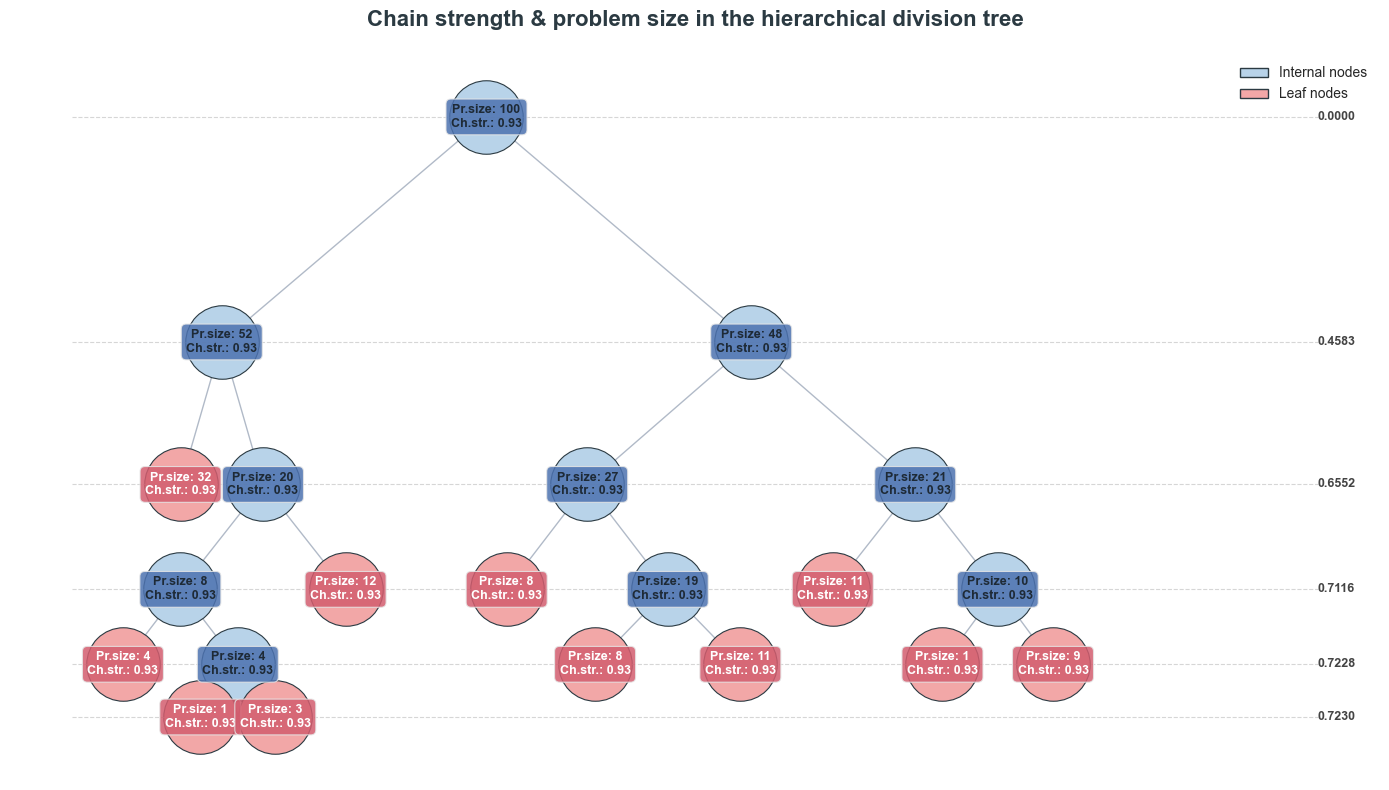

In [21]:
plot_tree(root)

In [23]:
extended_nodes = {nodes_k: DivisionNode(community_hash=node.id, node=node, sampleset_data=sampleset_metadata[nodes_k]) if nodes_k in sampleset_metadata.community_hash else DivisionNode(community_hash=node.id, node=node, sampleset_data=None) for nodes_k, node in nodes.items()}
extended_nodes

{7673536023032186979: ExtendedNode(id=7673536023032186979, community=[34, 52, 94, 99], left=None, right=None, community_hash=7673536023032186979, problem_id=f1cd9020-2aa7-45b8-9aa9-52557171d0db, chain_strength=None, chain_break_fraction=0.0, chain_break_method=None),
 1817303922367657890: ExtendedNode(id=1817303922367657890, community=[41], left=None, right=None, community_hash=1817303922367657890, problem_id=None, chain_strength=None, chain_break_fraction=None, chain_break_method=None),
 4244552301997251146: ExtendedNode(id=4244552301997251146, community=[20, 22, 68], left=None, right=None, community_hash=4244552301997251146, problem_id=84477ef3-22af-49a0-8986-9c9e1092075c, chain_strength=None, chain_break_fraction=0.0, chain_break_method=None),
 -2045999771114126478: ExtendedNode(id=-2045999771114126478, community=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None, community_hash=-2045999771114126478, problem_id=786b5468-b267-4386-82b3-df1e6a727a73, chain_strength=0.8942910530177813

In [25]:
for _, v in extended_nodes.items():
    if v.left:
        v.node.left = extended_nodes[v.left.id]
    if v.right:
        v.node.right = extended_nodes[v.right.id]
    # if v.parent:
    #     v.node.parent = extended_nodes[v.parent.id]

In [26]:
sampleset_metadata.chain_strength

[0.9556174135489324,
 0.8805108677638328,
 0.8409811131342095,
 0.8654292017399002,
 0.7773179979112785,
 None,
 None,
 None,
 0.9168041022297433,
 0.9294590057554593,
 0.9232368063592022,
 0.9088431561707252,
 0.9249397408915626,
 0.8942910530177813,
 0.918270849678021,
 0.9069475462493908,
 0.9114075996526694,
 0.865059336568957,
 0.911745399701482]

In [27]:
root_extended = DivisionNode(community_hash=root.id, node=root, sampleset_data=sampleset_metadata[root.id])

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def build_graph_extended(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""

    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)
    
    community_hash = node.community_hash
    community = node.values
    problem_id = node.problem_id
    chain_strength = node.chain_strength
    chain_break_fraction = node.chain_break_fraction

    label = divide_label(node.values)
    mod_value = division_modularities[level]
    # color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves


    G.add_node(node.id, label=label, mod_value=mod_value, values=community, level=level, chain_strength=chain_strength, chain_break_fraction=chain_break_fraction, community_hash=community_hash, problem_id=problem_id)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph_extended(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph_extended(G, node.right, level + 1)

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm


ROUND_DIGITS = 4


def center_parents(G, pos):
    """Center parents above children."""
    for n, data in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True):
        children = list(G.successors(n))
        if len(children) == 2:
            x1, _ = pos[children[0]]
            x2, _ = pos[children[1]]
            _, y = pos[n]
            pos[n] = ((x1 + x2)/2, y)
    return pos


def plot_tree_extended(root, figsize=(14,8), cmap=plt.cm.viridis, value=None):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph_extended(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    center_parents(G, pos)

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    # plt.figure(figsize=figsize)
    fig, ax = plt.subplots(figsize=figsize)
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           ax=ax,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           ax=ax,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           ax=ax,
                           alpha=0.6)
    


    cmap = cmap
    values = [G.nodes[n]['chain_strength'] for n in G.nodes()]
    valid_values = [v for v in values if v is not None]
    norm = mcolors.Normalize(vmin=min(valid_values), vmax=max(valid_values))
    # none_color = "#d3d3d3"
    none_color = "#CE6060"
    colors = {v: mcolors.to_hex(cmap(norm(v))) if v is not None else none_color for v in values}

    import math

    def is_bright(rgb, threshold=240):
        r, g, b = rgb
        lum = 0.2126*r + 0.7152*g + 0.0722*b
        return lum >= threshold
    
    def is_close_to_white(rgb, threshold=30):
        """
        rgb: (R, G, B) tuple, 0–255
        threshold: max distance from white to be considered 'close'
        """
        r, g, b = rgb
        # Euclidean distance to white
        dist = math.sqrt((255 - r)**2 + (255 - g)**2 + (255 - b)**2)
        return dist < threshold
    
    def is_close_to_gray(color_hex, sat_threshold=0.15):
        """
        Returns True if color is low saturation (grayish/whitish)
        color_hex: "#rrggbb"
        sat_threshold: maximum saturation allowed to still be considered 'gray'
        """
        rgb = mcolors.to_rgb(color_hex)
        h, s, v = mcolors.rgb_to_hsv(rgb)
        return s < sat_threshold

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']

        color = colors[node_data['chain_strength']]
        color_rgb = mcolors.to_rgb(color)
        rgb_255 = tuple(int(255 * x) for x in color_rgb)

        # if is_close_to_white(rgb_255, 30):
        # if is_bright(rgb_255, 200):
        if is_close_to_gray(color, sat_threshold=0.4):
            text_color = "#1e2a36"  # dark text for bright backgrounds
        else:
            text_color = "white"  # light text for dark backgrounds


        values = node_data['values']
        chain_strength = node_data['chain_strength']
        chain_break_fraction = node_data['chain_break_fraction']

        # label = f"{len(values)}\n{mod_value:.2f}"
        # text_color = "white" if node in leaves else "#1e2a36"
        # text_color = "white"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        ch_str_label = f"{chain_strength:.3f}" if chain_strength is not None else chain_strength
        label2 = f"Ch.str.: {ch_str_label}"
        cbf_label = f"{chain_break_fraction:.3f}" if chain_break_fraction is not None else chain_break_fraction
        label3 = f"CBF: {cbf_label}"
        # label = label1 + "\n" + label2
        label = label1 + "\n" + label2 + "\n" + label3

        ax.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [division_modularities[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx/2, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx), xmax=xmax+dx/2,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)
    


    # extended_colors = [none_color] + [cmap(i) for i in np.linspace(0, 1, 256)]
    # extended_cmap = ListedColormap(extended_colors)
    
    # sm = plt.cm.ScalarMappable(cmap=extended_cmap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.02)
    # ticks = ["None"] + sorted(set(valid_values))
    # cbar.set_ticks(ticks)
    # cbar.set_ticklabels([f"{t:.4f}" if t is not None else "None" for t in ticks])
    # cbar.set_label("Chain Strength", fontsize=10)
    
    # color_array = [cmap(i) for i in np.linspace(0, 1, 256)]
    # extended_colors = [mcolors.to_rgba(none_color)] + color_array
    # extended_cmap = ListedColormap(extended_colors)

    # # Normalization: 0 = None, numeric values from 0.0001 upwards
    # vmin, vmax = 0, max(valid_values)
    # norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # # Create ScalarMappable
    # sm = plt.cm.ScalarMappable(cmap=extended_cmap, norm=norm)
    # sm.set_array([])

    # # Plot colorbar
    # cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
    # cbar = plt.colorbar(sm, ax=ax, cax=cbar_ax, orientation="horizontal")

    # # Numeric ticks only! Map None to 0
    # ticks = [0] + list(np.linspace(min(valid_values), max(valid_values), 5))
    # cbar.set_ticks(ticks)
    # cbar.set_ticklabels(["None"] + [f"{t:.3f}" for t in ticks[1:]])
    # cbar.set_label("Chain strength", fontsize=10)

    valid_values_sorted = sorted(valid_values)

    # Create colormap
    cmap_vals = plt.cm.PuBu(np.linspace(0, 1, len(valid_values_sorted)))
    colors = np.vstack([mcolors.to_rgba(none_color), cmap_vals])
    discrete_cmap = ListedColormap(colors)

    # Create boundaries: first bin = None
    bounds = [-0.01] + valid_values_sorted
    norm = BoundaryNorm(bounds, discrete_cmap.N)

    # ScalarMappable
    sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
    sm.set_array([])

    # Colorbar
    # fig, ax = plt.subplots(figsize=(6,1))
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical")

    # Ticks
    ticks = [0] + valid_values_sorted
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["None"] + [f"{t:.3f}" for t in valid_values_sorted])
    cbar.set_label("Chain Strength", fontsize=10, labelpad=20)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    # plt.axis("off")
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel("Modularity")
    ax.yaxis.set_label_position("right") 
    plt.tight_layout()
    # plt.show()

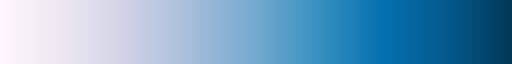

In [30]:
from matplotlib import colormaps
cmap = colormaps.get_cmap("PuBu")
cmap

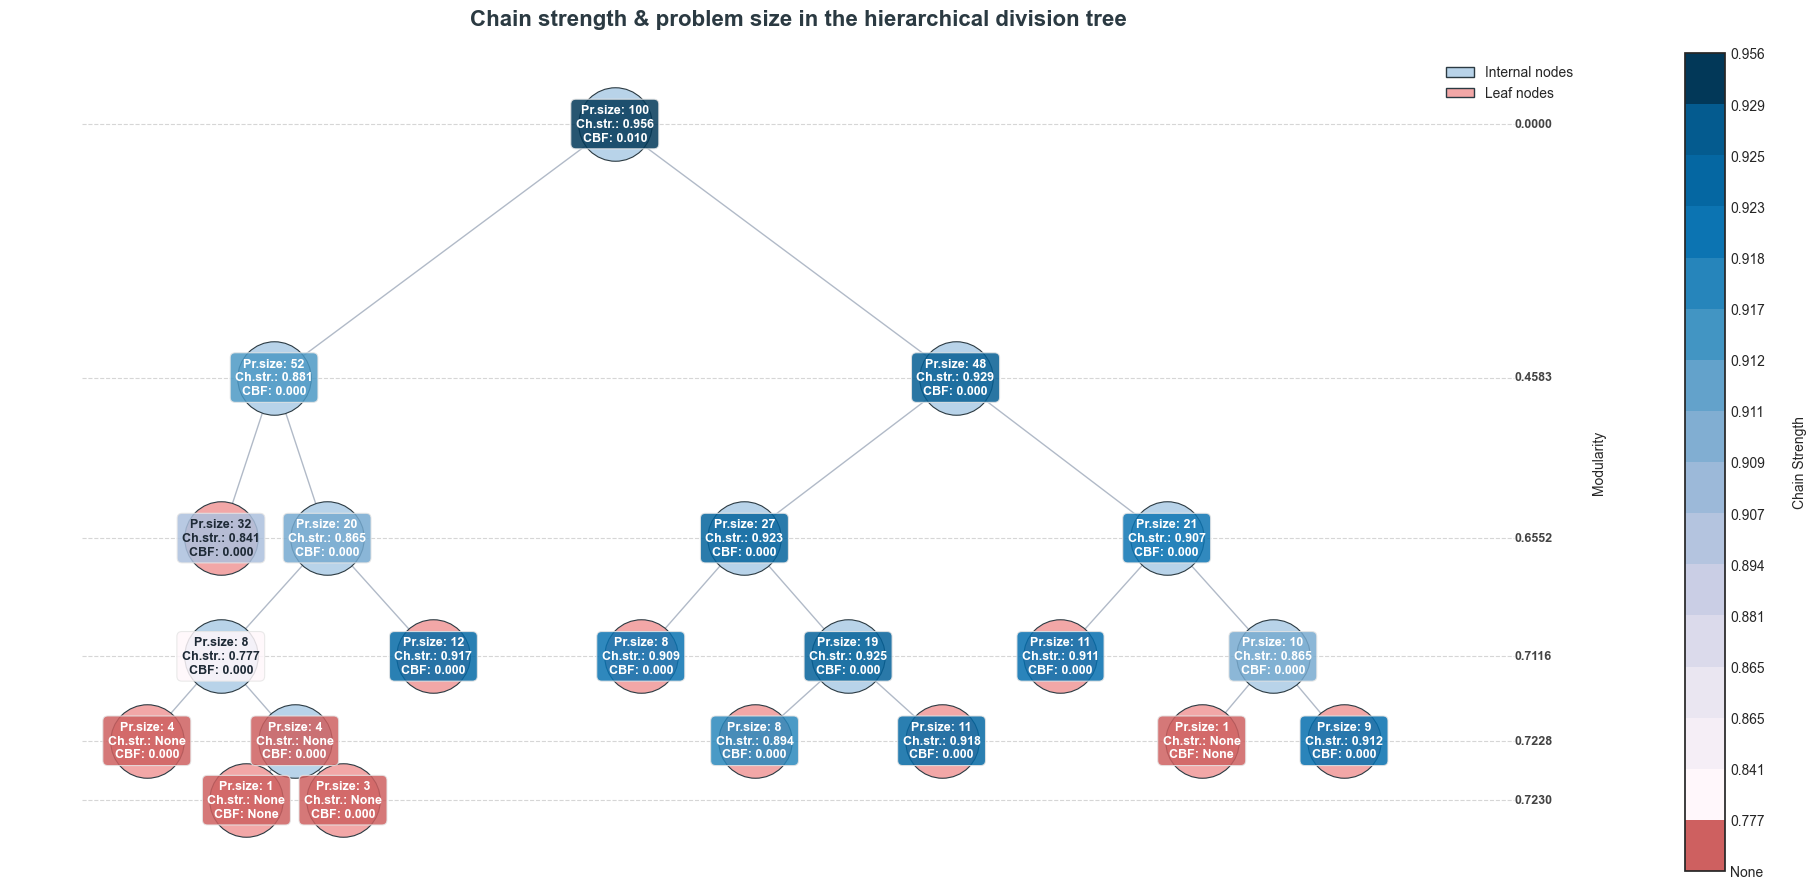

In [31]:
plot_tree_extended(root_extended, figsize=(20,9), cmap=cmap)

In [40]:
sampleset_sorted_by_problem_size = sorted(sampleset_metadata, key=lambda x: len(x.community), reverse=True)
pr_size = []
ch_str = []
cbf = []
pr_ids = []
for el in sampleset_sorted_by_problem_size:
    pr_size.append(len(el.community))
    ch_str.append(el.chain_strength)
    cbf.append(el.chain_break_fraction)
    pr_ids.append(el.problem_id)

In [41]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata


quadratics_mean = []
quadratics_std = []
linears_mean = []
linears_std = []
energies = []
for pr_id in pr_ids:
    pd = get_problem(pr_id)
    quads = np.array(list(pd.problem["quadratic"].values()))
    quadratics_mean.append(np.mean(quads))
    quadratics_std.append(np.std(quads))
    linears = np.array(list(pd.problem["linear"].values()))
    linears_mean.append(np.mean(linears))
    linears_std.append(np.std(linears))
    energies.append(pd.response.energies[0])

In [43]:
pr_size

[100, 52, 48, 32, 27, 21, 20, 19, 12, 11, 11, 10, 9, 8, 8, 8, 4, 4, 3]

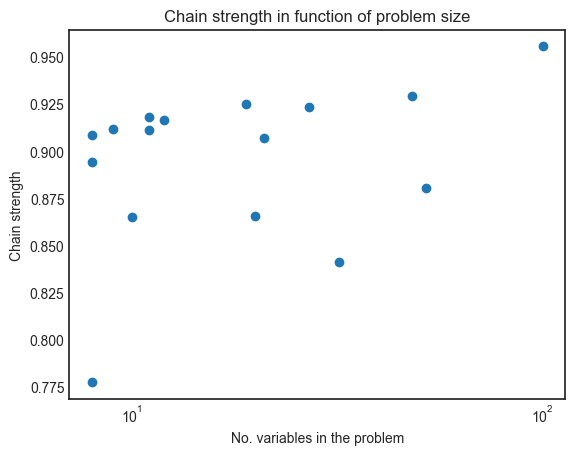

In [45]:
plt.scatter(pr_size, ch_str)
plt.title("Chain strength in function of problem size")
plt.xlabel("No. variables in the problem")
plt.ylabel("Chain strength");
plt.xscale("log")

In [48]:
sampleset_metadata.warnings

[[{'type': dwave.system.warnings.EnergyScaleWarning,
   'message': 'Some biases are 10^3 times stronger than others',
   'level': 30,
   'data': {'source_interactions': [(1125, 1110),
     (1125, 3005),
     (1126, 1111),
     (3020, 1110),
     (3020, 3005),
     (1127, 1112),
     (1128, 1113),
     (1129, 1114),
     (1130, 1115),
     (1131, 1116),
     (1132, 1117),
     (1133, 1118),
     (1155, 1140),
     (1155, 3035),
     (1156, 1141),
     (3050, 1140),
     (3050, 3035),
     (1157, 1142),
     (1158, 1143),
     (1159, 1144),
     (1160, 1145),
     (1161, 1146),
     (1162, 1147),
     (1035, 1020),
     (1035, 3065),
     (1036, 1021),
     (3080, 1020),
     (3080, 3065),
     (1037, 1022),
     (1038, 1023),
     (1039, 1024),
     (1040, 1025),
     (1041, 1026),
     (1042, 1027),
     (1043, 1028),
     (1005, 3065),
     (1005, 990),
     (1005, 3095),
     (1006, 991),
     (3110, 1020),
     (3110, 990),
     (3110, 3095),
     (1007, 992),
     (1008, 993),
    

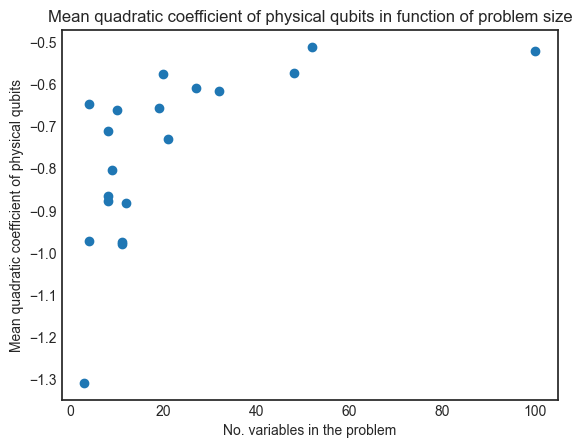

In [47]:
plt.scatter(pr_size, quadratics_mean)
plt.title("Mean quadratic coefficient of physical qubits in function of problem size")
plt.xlabel("No. variables in the problem")
plt.ylabel("Mean quadratic coefficient of physical qubits");

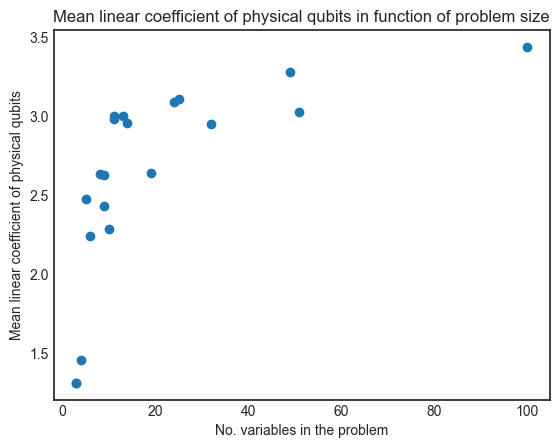

In [254]:
plt.scatter(pr_size, linears_mean)
plt.title("Mean linear coefficient of physical qubits in function of problem size");
plt.xlabel("No. variables in the problem")
plt.ylabel("Mean linear coefficient of physical qubits");

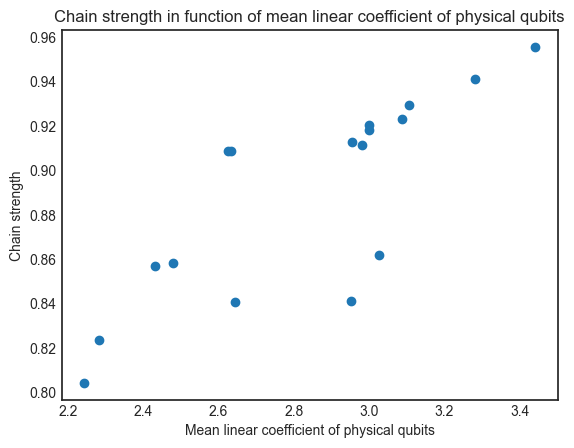

In [256]:
plt.scatter(linears_mean, ch_str)
plt.title("Chain strength in function of mean linear coefficient of physical qubits");
plt.xlabel("Mean linear coefficient of physical qubits")
plt.ylabel("Chain strength");

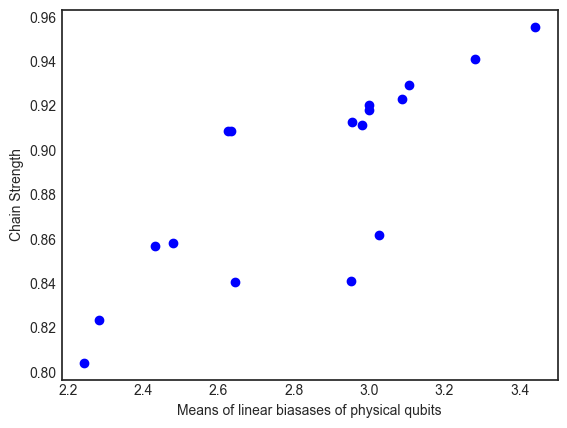

In [260]:
mask = np.array([v is not None for v in ch_str])
x_valid = np.array(linears_mean)[mask]
y_valid = np.array(ch_str)[mask]  # convert to array
yerr_valid = np.array(linears_std)[mask]

plt.scatter(x_valid, y_valid, color='blue', label='Data points')
# plt.errorbar(x_valid, y_valid, yerr=yerr_valid, fmt='none', ecolor='red', elinewidth=1.5, capsize=4)

plt.xlabel("Means of linear biasases of physical qubits")
plt.ylabel("Chain Strength")
# plt.legend()
plt.show()

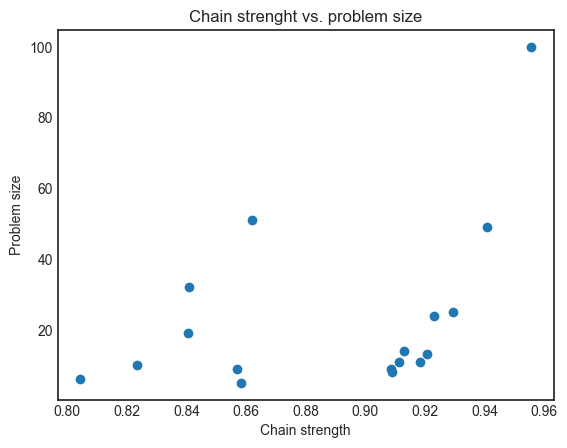

In [263]:
plt.scatter(ch_str, pr_size)
plt.title("Chain strenght vs. problem size");
plt.xlabel("Chain strength")
plt.ylabel("Problem size");

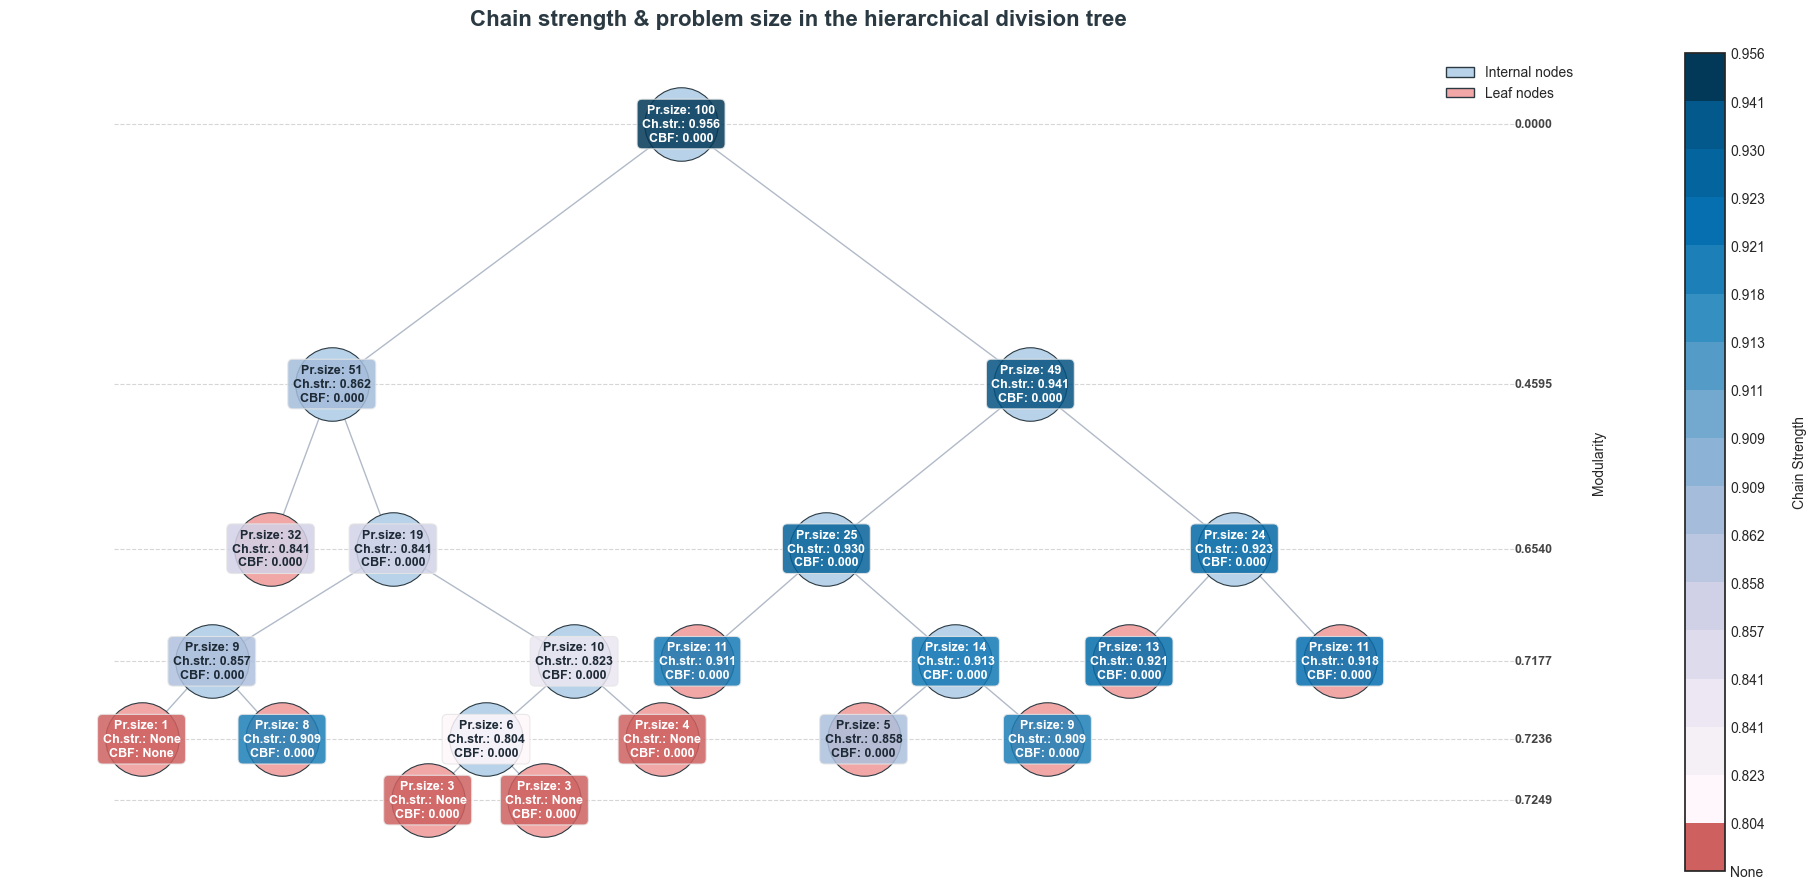

In [83]:
plot_tree_extended(root_extended, figsize=(20,9), cmap=cmap)

In [55]:
sampleset_metadata.embedding

[{'x0': (1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 2945),
  'x1': (1095, 1096, 1097, 1098, 1099, 1100, 1101, 1102, 1103, 2960),
  'x2': (1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 2975),
  'x3': (1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 2990),
  'x4': (1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 3005),
  'x5': (1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 3020),
  'x6': (1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 3035),
  'x7': (1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 3050),
  'x8': (1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 3065),
  'x9': (1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 3080),
  'x10': (990, 991, 992, 993, 994, 995, 996, 997, 3095),
  'x11': (1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 3110),
  'x12': (960, 961, 962, 963, 964, 965, 966, 967, 3125, 3126),
  'x13': (975, 976, 977, 978, 979, 980, 981, 982, 3140, 3141),
  'x14': (931, 932, 933, 934, 935, 936, 937, 938, 3155, 3156),
 

In [57]:
sampleset_metadata

HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(24068., 20., 200.1 , 39831.56, 1039.44, 15763.56, 20.58,  5.,  5.),
           (13716., 20.,  96.58, 29478.36,  891.64, 15762.36, 20.58,  1.,  1.),
           (20584., 20., 165.26, 36344.76,  761.24, 15760.76, 20.58, 57., 57.),
           (20020., 20., 159.62, 35781.96,  976.04, 15761.96, 20.58,  1.,  1.),
           (12500., 20.,  84.42, 28261.56,  785.44, 15761.56, 20.58, 17., 17.),
           (10628., 20.,  65.7 , 26388.76,  833.24, 15760.76, 20.58, 30., 30.),
           (10628., 20.,  65.7 , 26388.76,  699.24, 15760.76, 20.58,  1.,  1.),
           ( 8254., 20.,  41.96, 24015.56,  661.44, 15761.56, 20.58,  1.,  1.),
           (12676., 20.,  86.18, 28436.76,  903.24, 15760.76, 20.58,  1.,  1.),
           (13648., 20.,  95.9 , 29410.36,  610.64, 15762.36, 20.58, 29., 29.),
           (20884., 20., 168.26, 36645.56, 1001.44, 15761.56, 20.58,  1.,  1.),
           (12500., 20.,  84.42, 28261.56,  947.44, 15761.56, 20.58,  1

In [60]:
sampleset_metadata

HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(24068., 20., 200.1 , 39831.56, 1039.44, 15763.56, 20.58,  5.,  5.),
           (13716., 20.,  96.58, 29478.36,  891.64, 15762.36, 20.58,  1.,  1.),
           (20584., 20., 165.26, 36344.76,  761.24, 15760.76, 20.58, 57., 57.),
           (20020., 20., 159.62, 35781.96,  976.04, 15761.96, 20.58,  1.,  1.),
           (12500., 20.,  84.42, 28261.56,  785.44, 15761.56, 20.58, 17., 17.),
           (10628., 20.,  65.7 , 26388.76,  833.24, 15760.76, 20.58, 30., 30.),
           (10628., 20.,  65.7 , 26388.76,  699.24, 15760.76, 20.58,  1.,  1.),
           ( 8254., 20.,  41.96, 24015.56,  661.44, 15761.56, 20.58,  1.,  1.),
           (12676., 20.,  86.18, 28436.76,  903.24, 15760.76, 20.58,  1.,  1.),
           (13648., 20.,  95.9 , 29410.36,  610.64, 15762.36, 20.58, 29., 29.),
           (20884., 20., 168.26, 36645.56, 1001.44, 15761.56, 20.58,  1.,  1.),
           (12500., 20.,  84.42, 28261.56,  947.44, 15761.56, 20.58,  1

In [61]:
sampleset_metadata.chain_break_fraction

[np.float64(0.01),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

In [ ]:
fe = ["sampleset_adv.pkl", "sampleset_adv_serializable.pkl", "sampleset_adv.npy"]

In [145]:
import os
import re


hashes = list(nodes.keys())

result_files = []
result_files_handles = []
for root, dirs, files in os.walk("."):
    for file in files:
        match = re.search(r"comm_hash=(.*?)__id", file)
        if match:
            comm_hash = int(match.group(1))
            # pattern = rf"^.*comm_hash={comm_hash}.*_sampleset_adv.pkl$"
            pattern = rf"^.*comm_hash={comm_hash}.*"
            result_handle = re.search(pattern, file)
            if result_handle:
                # result_handle = re.split(rf"(_{fe[0]})$", result_handle.group(0))
                result_handle = re.split("sampleset", result_handle.group(0))
                if comm_hash in hashes:
                    result_files.append(os.path.join(root, file))
                    result_files_handles.append(result_handle[0])

In [146]:
result_files_handles

['n=100_comm_hash=-1119365825242883868__id=2d866f96-6ad1-4eb0-8e3b-86905c990246_',
 'n=100_comm_hash=-1119365825242883868__id=2d866f96-6ad1-4eb0-8e3b-86905c990246_',
 'n=100_comm_hash=-1119365825242883868__id=2d866f96-6ad1-4eb0-8e3b-86905c990246_',
 'n=100_comm_hash=-1211315125366653896__id=3aefc9ac-6375-4077-b8dc-2bb2eff72e59_',
 'n=100_comm_hash=-1211315125366653896__id=3aefc9ac-6375-4077-b8dc-2bb2eff72e59_',
 'n=100_comm_hash=-1211315125366653896__id=3aefc9ac-6375-4077-b8dc-2bb2eff72e59_',
 'n=100_comm_hash=-2045999771114126478__id=e2d0f352-68d1-4cec-9aa7-661f8eb9c933_',
 'n=100_comm_hash=-2045999771114126478__id=e2d0f352-68d1-4cec-9aa7-661f8eb9c933_',
 'n=100_comm_hash=-2045999771114126478__id=e2d0f352-68d1-4cec-9aa7-661f8eb9c933_',
 'n=100_comm_hash=-2251870041769838549__id=63b0b6e4-6f4d-4f08-864a-b9fb66dd0d2e_',
 'n=100_comm_hash=-2251870041769838549__id=63b0b6e4-6f4d-4f08-864a-b9fb66dd0d2e_',
 'n=100_comm_hash=-2251870041769838549__id=63b0b6e4-6f4d-4f08-864a-b9fb66dd0d2e_',
 'n=

In [ ]:
sampleset_metadata.

HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(24068., 20., 200.1 , 39831.56,   676.44, 15763.56, 20.58, 28., 28.),
           (19628., 20., 155.7 , 35393.16,   662.84, 15765.16, 20.58, 61., 61.),
           (20296., 20., 162.38, 36058.76,   638.24, 15762.76, 20.58,  1.,  1.),
           (14990., 20., 109.32, 30752.36,   604.64, 15762.36, 20.58,  1.,  1.),
           (12500., 20.,  84.42, 28263.56,   653.44, 15763.56, 20.58, 23., 23.),
           (21496., 20., 174.38, 37258.76,   590.24, 15762.76, 20.58,  1.,  1.),
           (20470., 20., 164.12, 36232.36,   607.64, 15762.36, 20.58,  1.,  1.),
           (20884., 20., 168.26, 36646.36,   550.64, 15762.36, 20.58,  1.,  1.),
           ( 6604., 20.,  25.46, 22366.76,  1894.24, 15762.76, 20.58, 27., 27.),
           (10628., 20.,  65.7 , 26390.36, 20783.64, 15762.36, 20.58,  1.,  1.),
           (13444., 20.,  93.86, 29208.36,   590.64, 15764.36, 20.58,  1.,  1.),
           (20296., 20., 162.38, 36058.76,  1321.24, 15762.7

In [149]:
np.load(result_files[0], allow_pickle=True)

TypeError: EmbeddedStructure is immutable